In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")
# receptor_reference = pl.read_parquet("../../data/iedb_meta/receptor_reference.parquet")

iedb_II_conf = (
    pl.read_parquet("../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_II/triad/iedb_II_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)
iedb_II = (
    (
        iedb_II_conf.explode("references", "receptor_id")
        .explode("references")
        .explode("receptor_id")
    )
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("receptor_id") == "missing")
        .then(pl.lit("x-ray crystallography"))
        .otherwise(pl.col("assay_type"))
        .alias("assay_type")
    )
    .filter(~pl.col("cognate") | pl.col("assay_type").is_not_null())
)


iedb_I_conf = (
    pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet")
    .drop(["receptor_id", "references"])
    .join(
        pl.read_parquet(
            "../../data/iedb_I/triad/iedb_I_triad.receptor_reference.parquet"
        ).select("job_name", "receptor_id", "references"),
        on="job_name",
        how="left",
    )
)
iedb_I = (
    (
        iedb_I_conf.explode("references", "receptor_id")
        .explode("references")
        .explode("receptor_id")
    )
    .join(
        assay_type,
        on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
        how="left",
    )
    .filter(~pl.col("cognate") | pl.col("assay_type").is_not_null())
)

# REMOVEME TO ADD BACK IN
iedb_II_annot = pl.read_parquet(
    "../../data/iedb_II_full/triad/iedb_II_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))

iedb_II = iedb_II.join(iedb_II_annot, on="job_name", how="anti")

# REMOVEME TO ADD BACK IN
iedb_I_annot = pl.read_parquet(
    "../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet"
).filter(pl.col("triad_in_pdb"))


iedb_I = iedb_I.join(iedb_I_annot, on="job_name", how="anti")

# additionally filter out
iedb_I = iedb_I.filter(pl.col("job_name") != "121f50b609621ebe92777820dad90eb9")

In [4]:
import matplotlib.pyplot as plt
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
import sklearn.metrics as metrics
from scipy.stats import mannwhitneyu, norm, false_discovery_control
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict, defaultdict
from matplotlib import transforms
from matplotlib.patches import Patch
from scipy.stats import kruskal
import matplotlib.ticker as mticker


def plot_violins(label, values, title=None):
    n = len(label)
    fig, ax = plt.subplots(figsize=(max(6, 0.8 * n), 4))

    vp = ax.violinplot(
        values,
        positions=range(1, n + 1),
        widths=0.8,
        showmedians=True,
        showextrema=False,
    )

    for body in vp["bodies"]:
        body.set_alpha(0.7)

    for i, vl_list in enumerate(values):
        ax.text(
            i + 1,
            0.95,
            f"n={len(vl_list)}\nmean={np.array(vl_list).mean():.2f}",
            ha="center",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.3),
        )

    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels(label, rotation=45, ha="right")
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylabel("AUC")
    plt.tight_layout()

    if title is not None:
        ax.set_title(title)

    return fig, ax


# def plot_violins_scatter(
#     label,
#     values,  # list[list[float]]
#     pos_triads,  # list[list[int]] aligned 1:1 with values
#     neg_triads,
#     title=None,
#     jitter=0.12,
#     point_size=25,
#     point_alpha=0.6,
#     label_y=0.05,
#     add_legend=True,
#     loc=(0.85, 0.15),
# ):
#     n = len(label)
#     if len(values) != len(pos_triads):
#         raise ValueError("values and pos_triads must have the same number of groups")

#     fig, ax = plt.subplots(figsize=(18, 5))

#     ax.axhline(0.5, linestyle="--", linewidth=1, color="black", alpha=1)
#     H, p = kruskal(*values)
#     print(
#         f"Kruskal–Wallis across {len(values)} groups: H={H:.3f}, df={len(values)-1}, p={p:.3g}"
#     )
#     ax.text(
#         loc[0],
#         loc[1],
#         f"K-W p={p:.1e}",
#         transform=ax.transAxes,
#         verticalalignment="top",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
#         fontsize=16,
#     )

#     # Violin plot
#     vp = ax.violinplot(
#         values,
#         positions=range(1, n + 1),
#         widths=0.8,
#         showmedians=True,
#         showextrema=False,
#     )
#     vp["cmedians"].set_linewidth(3)
#     vp["cmedians"].set_color("black")
#     for body in vp["bodies"]:
#         body.set_alpha(0.7)

#     # Overlay points with jitter; color encodes pos_triads
#     rng = np.random.default_rng()
#     for i, (vl_list, tri_list) in enumerate(zip(values, pos_triads)):
#         v = np.asarray(vl_list, dtype=float)
#         c = np.asarray(tri_list, dtype=float)
#         if v.shape != c.shape:
#             raise ValueError(f"pos_triads[{i}] must be same length as values[{i}]")

#         mask = np.isfinite(v)
#         v = v[mask]
#         c = c[mask]
#         if v.size == 0:
#             continue

#         x = np.full(v.shape, i + 1, dtype=float) + rng.uniform(
#             -jitter, jitter, size=v.size
#         )

#         # Color rules:
#         # 1 -> white; 2–9 -> yellow; >=10 -> green
#         colors = np.full(v.shape, "white", dtype=object)
#         colors[(c >= 2) & (c < 5)] = "yellow"
#         colors[(c >= 5) & (c < 10)] = "orange"
#         colors[c >= 10] = "green"

#         ax.scatter(
#             x,
#             v,
#             s=point_size,
#             alpha=point_alpha,
#             linewidths=0.5,
#             edgecolors="black",
#             c="white",
#             zorder=3,
#         )

#     # Labels above axes: show study count and total pos triads per group
#     trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
#     labs = []
#     for i, (vl_list, tri_list, neg_list) in enumerate(
#         zip(values, pos_triads, neg_triads)
#     ):
#         v = np.asarray(vl_list, dtype=float)
#         c = np.asarray(tri_list, dtype=float)
#         non = np.asarray(neg_list, dtype=float)
#         mask = np.isfinite(v)
#         studies = int(mask.sum())
#         total_pos = int(np.nansum(c[mask])) if studies > 0 else 0
#         total_neg = int(np.nansum(non) if studies > 0 else 0)

#         # ax.text(
#         #     i + 1,
#         #     label_y,
#         #     f"pMHC:studies={studies}\npos triads={total_pos}",
#         #     transform=trans,
#         #     ha="center",
#         #     va="bottom",
#         #     rotation=45,
#         #     fontsize=8,
#         #     bbox=dict(boxstyle="round,pad=0.3", alpha=0.3),
#         #     clip_on=False,
#         # )
#         if i == 0:
#             prefix1 = "n =     "
#             prefix2 = "# total cognates =   "
#             prefix3 = "# total non-cognates = "
#         else:
#             prefix1 = ""
#             prefix2 = ""
#             prefix3 = ""
#         label[i] = [
#             label[i],
#             f"\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n{prefix1}{studies}\n{prefix2}{total_pos}\n{prefix3}{total_neg}",
#         ]

#     label = [x for xs in label for x in xs]
#     xs = np.arange(1.15, n + 1.15, dtype=float)
#     eps = 0.005
#     ticks1 = xs - eps
#     ticks2 = xs + eps
#     all_ticks = [val for pair in zip(ticks1, ticks2) for val in pair]

#     # if add_legend:
#     #     handles = [
#     #         Patch(facecolor="white", edgecolor="black", label="pos=1"),
#     #         Patch(facecolor="yellow", edgecolor="black", label="2-4"),
#     #         Patch(facecolor="orange", edgecolor="black", label="5-9"),
#     #         Patch(facecolor="green", edgecolor="black", label="≥10"),
#     #     ]
#     #     ax.legend(
#     #         handles=handles, title="pos_triads", loc="lower right", framealpha=0.8
#     #     )

#     ax.tick_params(axis="y", labelsize=14)
#     ax.tick_params(axis="x", length=0)
#     ax.set_xticks(all_ticks)
#     ax.set_xticklabels(label, rotation=0, ha="right", fontsize=16)
#     # ax.tick_params(axis="x", which="major", pad=2)
#     ax.set_xlim(0.5, n + 0.5)
#     ax.set_ylabel("AUC", fontsize=16)

#     for label in ax.get_xmajorticklabels()[::2]:
#         label.set_rotation(90)

#     # ax.xaxis.set_minor_locator(mticker.FixedLocator(list(range(1, n + 1))))
#     # ax.xaxis.set_minor_formatter(
#     #     mticker.FixedFormatter(["SAMPLE" for _ in range(1, n + 1)])
#     # )
#     # ax.tick_params(
#     #     axis="x",
#     #     which="minor",
#     #     labelbottom=True,  # <-- this is the key
#     #     pad=18,
#     #     length=0,
#     #     labelsize=9,
#     # )
#     # for lbl in ax.get_xminorticklabels():
#     #     lbl.set_rotation(45)
#     #     lbl.set_ha("right")

#     if title is not None:
#         ax.set_title(title, fontsize=20)
#     return fig, ax


def multicolor_ylabel(ax, list_of_strings, list_of_colors, axis="x", anchorpad=0, **kw):
    """this function creates axes labels with multiple colors
    ax specifies the axes object where the labels should be drawn
    list_of_strings is a list of all of the text items
    list_if_colors is a corresponding list of colors for the strings
    axis='x', 'y', or 'both' and specifies which label(s) should be drawn"""
    from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker

    # x-axis label
    if axis == "x" or axis == "both":
        boxes = [
            TextArea(text, textprops=dict(color=color, ha="left", va="bottom", **kw))
            for text, color in zip(list_of_strings, list_of_colors)
        ]
        xbox = HPacker(children=boxes, align="center", pad=0, sep=0)
        anchored_xbox = AnchoredOffsetbox(
            loc=3,
            child=xbox,
            pad=anchorpad,
            frameon=False,
            bbox_to_anchor=(0, -0.5),
            bbox_transform=ax.transAxes,
            borderpad=0.0,
        )
        ax.add_artist(anchored_xbox)

    # y-axis label
    if axis == "y" or axis == "both":
        boxes = [
            TextArea(
                text,
                textprops=dict(color=color, ha="left", va="bottom", rotation=90, **kw),
            )
            for text, color in zip(list_of_strings[::-1], list_of_colors)
        ]
        ybox = HPacker(children=boxes, align="center", pad=0, sep=0)
        anchored_ybox = AnchoredOffsetbox(
            loc=3,
            child=ybox,
            pad=anchorpad,
            frameon=False,
            bbox_to_anchor=(-0.1, -0.7),
            bbox_transform=ax.transAxes,
            borderpad=0.0,
        )
        ax.add_artist(anchored_ybox)


def plot_violins_scatter(
    label,
    values,  # list[list[float]]
    pos_triads,  # list[list[int]] aligned 1:1 with values
    neg_triads,  # list[list[int]] aligned 1:1 with values
    title=None,
    jitter=0.12,
    point_size=25,
    point_alpha=0.6,
    add_legend=True,
    loc=(0.85, 0.15),
):
    n = len(label)
    if len(values) != len(pos_triads) or len(values) != len(neg_triads):
        raise ValueError(
            "values, pos_triads, neg_triads must have the same number of groups"
        )

    # --- Figure: 2 rows, shared x to align groups ---
    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[3, 1]),
    )

    # =========================
    # Top panel: violins + dots
    # =========================
    ax_top.axhline(0.5, linestyle="--", linewidth=1, color="black", alpha=1)

    H, p = kruskal(*values)
    ax_top.text(
        loc[0],
        loc[1],
        f"K-W p={p:.1e}",
        transform=ax_top.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=20,
    )

    vp = ax_top.violinplot(
        values,
        positions=range(1, n + 1),
        widths=0.8,
        showmedians=True,
        showextrema=False,
    )
    vp["cmedians"].set_linewidth(3)
    vp["cmedians"].set_color("black")
    for body in vp["bodies"]:
        body.set_alpha(0.7)

    rng = np.random.default_rng()
    for i, (vl_list, tri_list) in enumerate(zip(values, pos_triads)):
        v = np.asarray(vl_list, dtype=float)
        c = np.asarray(tri_list, dtype=float)
        if v.shape != c.shape:
            raise ValueError(f"pos_triads[{i}] must be same length as values[{i}]")
        mask = np.isfinite(v)
        v = v[mask]
        if v.size == 0:
            continue

        x = np.full(v.shape, i + 1, dtype=float) + rng.uniform(
            -jitter, jitter, size=v.size
        )

        # Point face color (kept simple; tweak if you want the thresholds back)
        ax_top.scatter(
            x,
            v,
            s=point_size,
            alpha=point_alpha,
            linewidths=0.5,
            edgecolors="black",
            c="white",
            zorder=3,
        )

    # Styling: hide x labels on TOP panel
    ax_top.tick_params(axis="x", labelbottom=False, length=0)
    ax_top.tick_params(axis="y", labelsize=20)
    ax_top.set_ylabel("AUC", fontsize=24)
    if title is not None:
        ax_top.set_title(title, fontsize=28)

    # =========================
    # Bottom panel: triple bars
    # =========================
    # For each group, compute: studies (n), total_pos, total_neg
    studies_arr = np.zeros(n, dtype=int)
    total_pos_arr = np.zeros(n, dtype=int)
    total_neg_arr = np.zeros(n, dtype=int)

    for i, (vl_list, tri_list, neg_list) in enumerate(
        zip(values, pos_triads, neg_triads)
    ):
        v = np.asarray(vl_list, dtype=float)
        pos = np.asarray(tri_list, dtype=float)
        neg = np.asarray(neg_list, dtype=float)

        mask = np.isfinite(v)
        studies = int(mask.sum())
        total_pos = int(np.nansum(pos[mask])) if studies > 0 else 0
        total_neg = int(np.nansum(neg[mask])) if studies > 0 else 0

        studies_arr[i] = studies
        total_pos_arr[i] = total_pos
        total_neg_arr[i] = total_neg

    # Grouped bars centered at x = 1..n (same centers as violins)
    xs = np.arange(1, n + 1, dtype=float)
    bw = 0.22  # bar width
    offsets = (-bw, 0.0, +bw)  # left/middle/right inside each group
    ax_bot.set_yscale("log")
    ax_bot.set_yticks([10**i for i in range(0, 6)])
    ax_bot.tick_params(axis="y", labelsize=20)

    bars1 = ax_bot.bar(
        xs + offsets[0], studies_arr, width=bw, label="n (studies)", color="tab:blue"
    )
    bars2 = ax_bot.bar(
        xs + offsets[1],
        total_pos_arr,
        width=bw,
        label="# total cognates",
        color="tab:green",
    )
    bars3 = ax_bot.bar(
        xs + offsets[2],
        total_neg_arr,
        width=bw,
        label="# total non-cognates",
        color="tab:red",
    )
    # handles = [
    #     Patch(
    #         facecolor=bars1.patches[0].get_facecolor(),
    #         edgecolor="black",
    #         label="n (studies)",
    #     ),
    #     Patch(
    #         facecolor=bars2.patches[0].get_facecolor(),
    #         edgecolor="black",
    #         label="# total cognates",
    #     ),
    #     Patch(
    #         facecolor=bars3.patches[0].get_facecolor(),
    #         edgecolor="black",
    #         label="# total non-cognates",
    #     ),
    # ]

    # leg = ax_bot.legend(
    #     handles=handles,
    #     loc="center left",
    #     bbox_to_anchor=(-0.18, 0.5),  # tweak -0.18 as needed
    #     frameon=True,
    #     borderaxespad=0.0,
    #     fontsize=14,
    #     # title="Counts",
    # )
    import math

    max_lg = int(math.log(max(total_neg_arr), 10))

    # Bottom axis labels: put ONLY the group names here
    ax_bot.set_xlim(0.5, n + 0.5)
    ax_bot.set_xticks(xs)
    ax_bot.set_xticklabels(label, rotation=45, ha="right", fontsize=20)  # group labels
    ax_bot.set_ylabel(None)
    multicolor_ylabel(
        ax_bot,
        ["# non-cognate triads", "# cognate triads", "# study:antigens"],
        ["tab:blue", "tab:green", "tab:red"],
        axis="y",
        fontsize=24,
    )
    ax_bot.set_yticks([10**i for i in range(max_lg + 1)])
    ax_bot.tick_params(axis="x", length=0)

    fig.tight_layout()
    return fig, (ax_top, ax_bot)


def auc_by(
    df,
    featnames,
    mhc_class,
):
    grouping_cols = FORMAT_ANTIGEN_COLS + ["references"]
    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))
        # at = (
        #     assay_type.filter(pl.col("references") == row["references"])
        #     .select("assay_type")
        #     .to_series()
        #     .to_list()
        # )
        ref = row["references"]
        if mhc_class == "I":
            hla = row["mhc_1_name"]
            antigen = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            hla = row["mhc_2_name"]
            antigen = row["mhc_2_name"] + "::" + row["peptide"]

        focal_pos = df.join(focal_a_st, on=grouping_cols)
        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))
        pos_triad = focal_pos.height

        focal_triad = pl.concat([focal_pos, focal_neg])

        for feat in featnames:
            dat = focal_triad.select(feat, "cognate").to_numpy()

            fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
            # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
            roc_auc = metrics.auc(fpr, tpr)

            feat_df.append(
                {
                    "auc": roc_auc,
                    # "fpr": list(fpr),
                    # "tpr": list(tpr),
                    "featname": feat,
                    "hla": hla,
                    "antigen": antigen,
                    "ref": ref,
                    "pos_triad": pos_triad,
                }
            )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


def auc_assay_type(
    df,
    featnames,
    mhc_class,
):
    grouping_cols = FORMAT_ANTIGEN_COLS + ["references"]
    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))

        ref = row["references"]
        if mhc_class == "I":
            hla = row["mhc_1_name"]
            antigen = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            hla = row["mhc_2_name"]
            antigen = row["mhc_2_name"] + "::" + row["peptide"]

        focal_pos = df.filter(pl.col("cognate")).join(focal_a_st, on=grouping_cols)

        # if focal_pos.select("job_name").join(BROKEN, on="job_name").height != 0:
        #     print("hello")

        # focal_pos = focal_pos.join(
        #     receptor_reference,
        #     left_on=["references", "receptor_id"],
        #     right_on=["reference_id", "receptor_id"],
        # )

        # focal_pos = focal_pos.explode("receptor_id").join(
        #     assay_type,
        #     left_on=["receptor_id"],
        #     right_on=["receptor_id"],
        # )

        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))

        focal_pos_by_at = focal_pos.partition_by("assay_type")

        for at_partition in focal_pos_by_at:
            at = at_partition.select("assay_type")[0].item()
            # if at == "x-ray crystallography":
            #     JN_LS.append(
            #         at_partition.select("job_name").unique().to_series().to_list()
            #     )
            focal_triad = pl.concat(
                [
                    at_partition.select(
                        pl.exclude("assay_type", "receptor_id")
                    ).unique(),
                    focal_neg.select(pl.exclude("assay_type", "receptor_id")),
                ]
            )
            pos_triad = at_partition.height
            neg_triad = focal_neg.height

            for feat in featnames:
                dat = focal_triad.select(feat, "cognate").to_numpy()

                fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
                # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
                roc_auc = metrics.auc(fpr, tpr)

                feat_df.append(
                    {
                        "auc": roc_auc,
                        # "fpr": list(fpr),
                        # "tpr": list(tpr),
                        "featname": feat,
                        "assay_type": at,
                        "antigen": antigen,
                        "pos_triad": pos_triad,
                        "neg_triad": neg_triad,
                        "job_names": at_partition.select("job_name")
                        .unique()
                        .to_series()
                        .to_list(),
                        "references": at_partition.select("references")
                        .unique()
                        .to_series()
                        .to_list(),
                    }
                )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


feats = [
    "iptm",
    "mean_p_tcr_interface_pae",
]

## By antigen:study


In [3]:
auc_partition_II = auc_by(
    iedb_II,
    feats,
    "II",
)
auc_partition_I = auc_by(
    iedb_I,
    feats,
    "I",
)

In [5]:
auc_at_II = auc_assay_type(
    iedb_II.with_columns(
        (31 - pl.col("mean_p_tcr_interface_pae")).alias("mean_p_tcr_interface_pae")
    ),
    feats,
    "II",
)
auc_at_I = auc_assay_type(
    iedb_I.with_columns(
        (31 - pl.col("mean_p_tcr_interface_pae")).alias("mean_p_tcr_interface_pae")
    ),
    feats,
    "I",
)

In [ ]:
auc_at_I.filter(pl.col("featname") == "iptm").explode("job_names").group_by(
    "job_names"
).agg(pl.col("assay_type"), pl.count()).sort("count", descending=True).select(
    pl.col("job_names")
)[
    0
].item()

iedb_I.filter(pl.col("job_name") == "31f715883027c497e879f114daff627b").select(
    "references"
).unique()

/tmp/ipykernel_2638618/1710846230.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  auc_at_I.filter(pl.col("featname") == "iptm").explode("job_names").group_by("job_names").agg(pl.col("assay_type"), pl.count()).sort("count", descending=True).select(pl.col("job_names"))[0].item()


references
str
"""1025272"""
"""1028747"""


## AUC stats


In [4]:
auc_at_I.filter(pl.col("featname") == "mean_p_tcr_interface_pae").group_by(
    "assay_type"
).agg(pl.col("auc").median()).sort(by="auc")

assay_type,auc
str,f64
"""multimer/tetramer""",0.61
"""ICS""",0.625
"""cytometric bead array""",0.64
"""in vivo assay""",0.687143
"""51 chromium""",0.71
…,…
"""surface plasmon resonance (SPR…",0.847826
"""intracellular staining""",0.88
"""reporter gene assay""",0.892564


In [5]:
auc_at_II.filter(pl.col("featname") == "mean_p_tcr_interface_pae").group_by(
    "assay_type"
).agg(pl.col("auc").median()).sort(by="auc")

assay_type,auc
str,f64
"""ELISPOT""",0.435
"""multimer/tetramer""",0.523519
"""surface plasmon resonance (SPR…",0.55
"""cytometric bead array""",0.555662
"""3H-thymidine""",0.608
…,…
"""bioassay""",0.877451
"""51 chromium""",0.92
"""binding assay""",0.935


## Num antigen-studies per assay type


In [6]:
auc_at_I.filter(pl.col("featname") == "iptm").group_by("assay_type").agg(
    pl.col("antigen").len()
).sort(by="antigen")

assay_type,antigen
str,u32
"""CFSE""",1
"""intracellular staining""",3
"""cytometric bead array""",6
"""reporter gene assay""",6
"""in vivo assay""",8
…,…
"""binding assay""",57
"""ICS""",69
"""ELISA""",85


In [7]:
auc_at_II.filter(pl.col("featname") == "iptm").group_by("assay_type").agg(
    pl.col("antigen").len()
).sort(by="antigen")

assay_type,antigen
str,u32
"""in vivo assay""",2
"""cytometric bead array""",2
"""reporter gene assay""",3
"""surface plasmon resonance (SPR…",3
"""ICS""",3
…,…
"""CFSE""",17
"""multimer/tetramer""",30
"""ELISA""",75


## Proportion of cognate triads by assay type


In [6]:
auc_at_I.filter(pl.col("featname") == "iptm").group_by("assay_type").agg(
    pl.col("pos_triad").sum()
    / auc_at_I.filter(pl.col("featname") == "iptm")
    .select(pl.col("pos_triad"))
    .sum()
    .item()
).sort(by="pos_triad")

assay_type,pos_triad
str,f64
"""CFSE""",0.00022
"""reporter gene assay""",0.000661
"""intracellular staining""",0.000661
"""in vivo assay""",0.001212
"""cytometric bead array""",0.001653
…,…
"""ELISPOT""",0.014878
"""ELISA""",0.031629
"""ICS""",0.046286


In [7]:
auc_at_II.filter(pl.col("featname") == "iptm").group_by("assay_type").agg(
    pl.col("pos_triad").sum()
    / auc_at_II.filter(pl.col("featname") == "iptm")
    .select(pl.col("pos_triad"))
    .sum()
    .item()
).sort(by="pos_triad")

assay_type,pos_triad
str,f64
"""surface plasmon resonance (SPR…",0.000903
"""in vivo assay""",0.000903
"""ICS""",0.000903
"""reporter gene assay""",0.001203
"""bioassay""",0.001504
…,…
"""3H-thymidine""",0.038809
"""ELISA""",0.050241
"""cytometric bead array""",0.065283


(<Figure size 1800x1000 with 2 Axes>,
 (<Axes: title={'center': 'Classification Performance per IEDB Assay Type (Class II)'}, ylabel='AUC'>,
  <Axes: >))

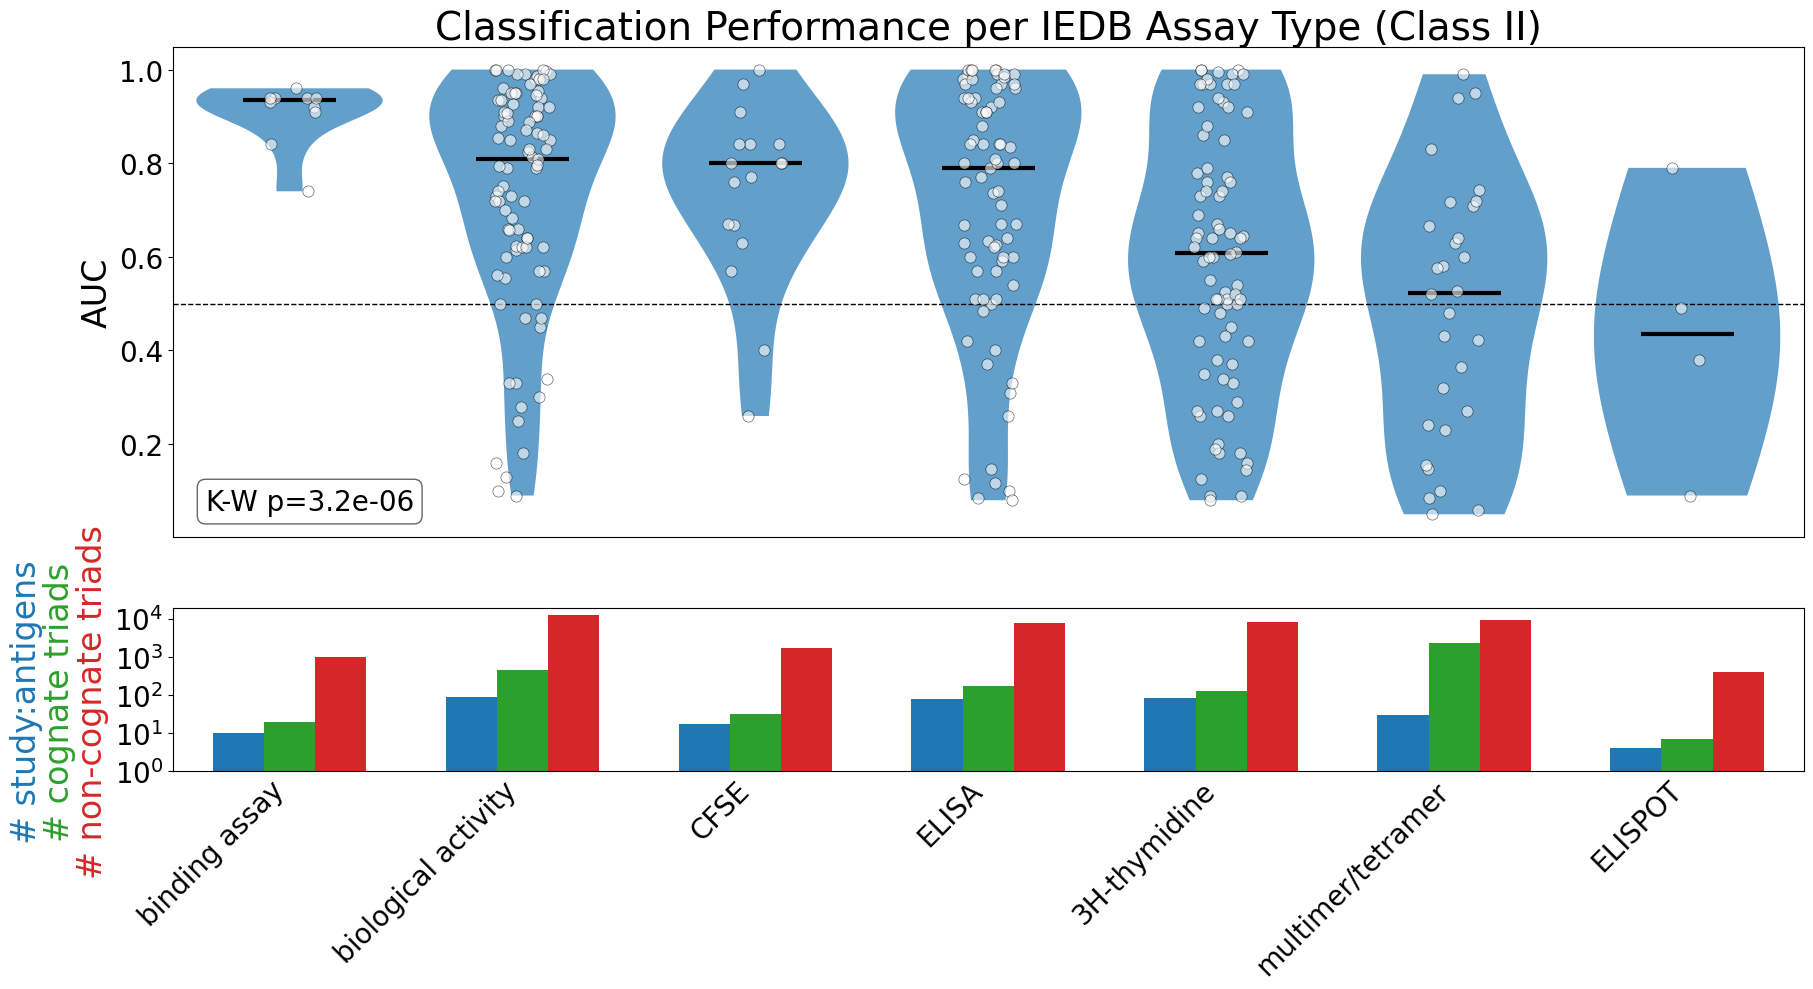

In [7]:
featname = "mean_p_tcr_interface_pae"


auc_partition_II_antigen = (
    (
        auc_at_II.filter(pl.col("featname") == featname)
        .group_by(pl.col("assay_type"))
        .agg(
            pl.col("auc"),
            pl.col("pos_triad"),
            pl.len().alias("n_as"),
            pl.col("neg_triad"),
            pl.col("auc").median().alias("med_auc"),
        )
    )
    .filter(pl.col("n_as") >= 4)
    .sort(by=pl.col("med_auc"), descending=True)
)


plot_violins_scatter(
    auc_partition_II_antigen.select("assay_type").to_series().to_list(),
    auc_partition_II_antigen.select("auc").to_series().to_list(),
    auc_partition_II_antigen.select("pos_triad").to_series().to_list(),
    auc_partition_II_antigen.select("neg_triad").to_series().to_list(),
    title="Classification Performance per IEDB Assay Type (Class II)",
    loc=(0.02, 0.1),
    point_size=65,
)

In [12]:
iedb_I.filter(pl.col("assay_type") == "binding assay").select(
    "references"
).unique().to_series().to_list()

['1032888', '1033026', '1032856', '1039796', '1037171', '1034243', '1041763']

## Validating 8PJG exclusion


In [ ]:
pl.read_parquet(
    "../../data/iedb_II_corrected/triad/iedb_II_corrected_triad.cleaned.parquet"
).explode("references").explode("references").explode("receptor_id").explode(
    "receptor_id"
).filter(
    pl.col("peptide") == "PKYVKQNTLKLAR"
).join(
    assay_type,
    on=["references", "receptor_id", "peptide", "mhc_1_name", "mhc_2_name"],
    how="left",
)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,tcell_id,mhc_class_right,assay_type
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str
"""089c9978ec43329d48ddcc0c3e5d68…",true,"""PKYVKQNTLKLAR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*01:01""","""GDTRPRFLWQLKFECHFFNGTERVRLLERC…","""alpha""","""human""","""AQSVTQLGSHVSVSEGALVLLRCNYSSSVP…","""beta""","""human""","""DVKVTQSSRYLVKRTGEKVFLECVQDMDHE…","""SSVPPY""","""YTSAATLV""","""KKSETS""","""CAVSESPFGNEKLTF""","""MDHEN""","""SYDVKM""","""EKKER""","""CASSSTGLPYGYTF""","""28368""","""1032401""",3805496,"""II""","""surface plasmon resonance (SPR…"
"""72cf56951cdb3e495dbac1dd94ea3d…",true,"""PKYVKQNTLKLAR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*04:01""","""GDTRPRFLEQVKHECHFFNGTERVRFLDRY…","""alpha""","""human""","""AQSVTQLGSHVSVSEGALVLLRCNYSSSVP…","""beta""","""human""","""DVKVTQSSRYLVKRTGEKVFLECVQDMDHE…","""SSVPPY""","""YTSAATLV""","""KKSETS""","""CAVSESPFGNEKLTF""","""MDHEN""","""SYDVKM""","""EKKER""","""CASSSTGLPYGYTF""","""28368""","""1032401""",3804158,"""II""","""surface plasmon resonance (SPR…"
"""ad86a45b334f65c226f01f0a2f2560…",true,"""PKYVKQNTLKLAR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*01:01""","""GDTRPRFLWQLKFECHFFNGTERVRLLERC…","""alpha""","""human""","""AQSVTQLGSHVSVSEGALVLLRCNYSSSVP…","""beta""","""human""","""DADVTQTPRNRITKTGKRIMLECSQTKGHD…","""SSVPPY""","""YTSAATLV""","""KKSETS""","""CAVSEQDDKIIF""","""KGHDR""","""SFDVKD""","""QAQAK""","""CATSDESYGYTF""","""28369""","""1032401""",3804161,"""II""","""surface plasmon resonance (SPR…"
"""ad86a45b334f65c226f01f0a2f2560…",true,"""PKYVKQNTLKLAR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*01:01""","""GDTRPRFLWQLKFECHFFNGTERVRLLERC…","""alpha""","""human""","""AQSVTQLGSHVSVSEGALVLLRCNYSSSVP…","""beta""","""human""","""DADVTQTPRNRITKTGKRIMLECSQTKGHD…","""SSVPPY""","""YTSAATLV""","""KKSETS""","""CAVSEQDDKIIF""","""KGHDR""","""SFDVKD""","""QAQAK""","""CATSDESYGYTF""","""missing""","""8PJG""",null,null,null


In [5]:
auc_at_II.filter(
    pl.col("featname") == "iptm", pl.col("assay_type") == "x-ray crystallography"
)

auc,featname,assay_type,antigen,pos_triad,neg_triad,job_names,references
f64,str,str,str,i64,i64,list[str],list[str]
0.835,"""iptm""","""x-ray crystallography""","""DRB1*04:01::EIFDSRGNPTGEV""",1,100,"[""ab510bae23e6d35fe62aa00a1b341aff""]","[""8TRL""]"
0.595,"""iptm""","""x-ray crystallography""","""DRB1*04:01::GVYATRSSAVRLR""",1,100,"[""4e9dd0f256138628dc0f202092717100""]","[""8TRQ""]"
0.515,"""iptm""","""x-ray crystallography""","""DRB1*04:01::GVYATRSSAVRLR""",1,100,"[""808f6f54df391ceaf707ef0b2629e23a""]","[""8TRR""]"
0.696078,"""iptm""","""x-ray crystallography""","""DQB1*03:02::GQVELGGGNAVEVCK""",1,102,"[""5342efe9f1b5163aa3dbfc9c016d971c""]","[""8VD0""]"
0.905,"""iptm""","""x-ray crystallography""","""DQB1*03:02::GQVELGGGTPIESCQ""",1,100,"[""163d77ab825868a3b14f500cfed4b66c""]","[""8VD2""]"
0.865,"""iptm""","""x-ray crystallography""","""DQB1*03:02::GQVELGGGSSPETCI""",1,100,"[""296fb62b49fbd72c9342c773e82e3aa6""]","[""8VCY""]"
0.985,"""iptm""","""x-ray crystallography""","""DQB1*03:02::GQVELGGGPGAESCQ""",1,100,"[""31886ecd5142547d462de1de709cec7d""]","[""8VCX""]"


In [ ]:
import editdistance

featname = "iptm"

tmp = (
    auc_at_II.filter(pl.col("featname") == featname)
    .filter(pl.col("assay_type") == "x-ray crystallography")
    .explode("job_names", "references")
    .sort(by="auc")
    .join(iedb_II, left_on="job_names", right_on="job_name")
    .select(
        "references",
        featname,
        "auc",
        "peptide",
        "mhc_1_name",
        "mhc_2_name",
        "cognate",
        "tcr_1_cdr_3",
        "tcr_2_cdr_3",
        "tcr_1_seq",
        "tcr_2_seq",
        "job_names",
        "mhc_1_seq",
        "mhc_2_seq",
    )
)


pdb = pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/pdb/triad/pdb_triad.conf_af3.parquet"
)


# peptides match, cdrs match
tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb")).join(
    pdb, on="pdb"
).select(
    "auc",
    "iptm",
    "iptm_right",
    "tcr_1_cdr_3",
    "tcr_1_cdr_3_right",
    "tcr_2_cdr_3",
    "tcr_2_cdr_3_right",
    "peptide",
    "peptide_right",
)

i = 2

print(
    tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb"))
    .join(pdb, on="pdb")
    .with_columns(
        pl.struct([pl.col("tcr_1_seq"), pl.col("tcr_1_seq_right")])
        .map_elements(
            lambda x: editdistance.eval(x["tcr_1_seq"], x["tcr_1_seq_right"]),
            return_dtype=pl.Int64,
        )
        .alias("tcr_1_seq_edit_distance"),
    )
    .sort(by="auc")
    .select("tcr_1_seq")[i]
    .item()
)

print(
    tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb"))
    .join(pdb, on="pdb")
    .with_columns(
        pl.struct([pl.col("tcr_1_seq"), pl.col("tcr_1_seq_right")])
        .map_elements(
            lambda x: editdistance.eval(x["tcr_1_seq"], x["tcr_1_seq_right"]),
            return_dtype=pl.Int64,
        )
        .alias("tcr_1_seq_edit_distance"),
    )
    .sort(by="auc")
    .select("tcr_1_seq_right")[i]
    .item()
)


tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb")).join(
    pdb, on="pdb"
).select(
    pl.col("tcr_1_seq").str.len_chars().alias("tcr_1_seq_len"),
    pl.col("tcr_1_seq_right").str.len_chars().alias("tcr_1_seq_right_len"),
    pl.col("tcr_2_seq").str.len_chars().alias("tcr_2_seq_len"),
    pl.col("tcr_2_seq_right").str.len_chars().alias("tcr_2_seq_right_len"),
)


tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb")).join(
    pdb, on="pdb"
).select(
    "pdb",
    "iptm",
    "iptm_right",
    "peptide",
    "mhc_1_seq",
    "mhc_2_seq",
    "tcr_1_seq",
    "tcr_2_seq",
    "peptide_right",
    "mhc_1_seq_right",
    "mhc_2_seq_right",
    "tcr_1_seq_right",
    "tcr_2_seq_right",
).write_csv(
    "iedb_II_xray_crystal_matching_pdb.tsv", separator="\t"
)

# .select("auc", "iptm", "iptm_right", "tcr_1_seq", "tcr_2_seq")

DAKTTQPPSMDCAEGRAANLPCNHSTISGNEYVYWYRQIHSQGPQYIIHGLKNNETNEMASLIITEDRKSSTLILPHATLRDTAVYYCIVSHNAGNMLTFGGGTRLMVKPH
MKTTQPPSMDCAEGRAANLPCNHSTISGNEYVYWYRQIHSQGPQYIIHGLKNNETNEMASLIITEDRKSSTLILPHATLRDTAVYYCIVSHNAGNMLTFGGGTRLMVKPHIQNPDPAVYQLRDSKSSDKSVCLFTDFDSQTNVSQSKDSDVYITDKCVLDMRSMDFKSNSAVAWSNKSDFACANAFNNSIIPEDTFFPSPESS


JG IS MISSING!


In [ ]:
tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb")).join(
    pdb, on="pdb"
).select(
    "auc",
    "iptm",
    "iptm_right",
    "tcr_1_cdr_3",
    "tcr_1_cdr_3_right",
    "tcr_2_cdr_3",
    "tcr_2_cdr_3_right",
    "peptide",
    "peptide_right",
)

auc,iptm,iptm_right,tcr_1_cdr_3,tcr_1_cdr_3_right,tcr_2_cdr_3,tcr_2_cdr_3_right,peptide,peptide_right
f64,f64,f64,str,str,str,str,str,str
0.696078,0.86,0.85,"""CIVRVAIEGSQGNLIF""","""CIVRVAIEGSQGNLIF""","""CASSLRRGDTIYF""","""CASSLRRGDTIYF""","""GQVELGGGNAVEVCK""","""GQVELGGGNAVEVCKG"""
0.515,0.85,0.89,"""CALGDTGNYKYVF""","""CALGDTGNYKYVF""","""CASSAVNSGNTLYF""","""CASSAVNSGNTLYF""","""GVYATRSSAVRLR""","""GVYATRSSAVRLR"""
0.985,0.91,0.88,"""CIVSHNAGNMLTF""","""CIVSHNAGNMLTF""","""CASSLERETQYF""","""CASSLERETQYF""","""GQVELGGGPGAESCQ""","""GQVELGGGPGAESCQ"""
0.905,0.89,0.88,"""CIVRVAIEGSQGNLIF""","""CIVRVAIEGSQGNLIF""","""CASSLRRGDTIYF""","""CASSLRRGDTIYF""","""GQVELGGGTPIESCQ""","""GQVELGGGTPIESCQ"""
0.865,0.89,0.88,"""CIVSHNAGNMLTF""","""CIVSHNAGNMLTF""","""CASSLERETQYF""","""CASSLERETQYF""","""GQVELGGGSSPETCI""","""GQVELGGGSSPETCI"""


In [ ]:
pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_II_corrected/triad/staged/iedb_II_corrected_triad.annotated.parquet"
).explode("receptor_id").explode("receptor_id").filter(
    pl.col("receptor_id") == "missing"
)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,pmhc_in_validation
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[list[str]],bool
"""163d77ab825868a3b14f500cfed4b6…",true,"""GQVELGGGTPIESCQ""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVRVAIEGSQGNLIF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLRRGDTIYF""","""missing""","[[""8VD2""]]",false
"""296fb62b49fbd72c9342c773e82e3a…",true,"""GQVELGGGSSPETCI""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVSHNAGNMLTF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLERETQYF""","""missing""","[[""8VCY""]]",false
"""31886ecd5142547d462de1de709cec…",true,"""GQVELGGGPGAESCQ""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVSHNAGNMLTF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLERETQYF""","""missing""","[[""8VCX""]]",false
"""4e9dd0f256138628dc0f2020927171…",true,"""GVYATRSSAVRLR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*04:01""","""GDTRPRFLEQVKHECHFFNGTERVRFLDRY…","""alpha""","""human""","""GDSVTQMEGPVTLSEEAFLTINCTYTATGY…","""beta""","""human""","""DGGITQSPKYLFRKEGQNVTLSCEQNLNHD…","""TTSIAYPN""","""VITAGQK""","""NKETTS""","""CALGDHSGSWQLIF""","""FNHDT""","""SITEND""","""EKKSS""","""CASSLRTGANSDYTF""","""missing""","[[""8TRQ""]]",false
"""5342efe9f1b5163aa3dbfc9c016d97…",true,"""GQVELGGGNAVEVCK""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVRVAIEGSQGNLIF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLRRGDTIYF""","""missing""","[[""8VD0""]]",false
"""808f6f54df391ceaf707ef0b2629e2…",true,"""GVYATRSSAVRLR""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*04:01""","""GDTRPRFLEQVKHECHFFNGTERVRFLDRY…","""alpha""","""human""","""GDSVTQMEGPVTLSEEAFLTINCTYTATGY…","""beta""","""human""","""DAGITQSPRYKITETGRQVTLMCHQTWSHS…","""TTSIAYPN""","""VITAGQK""","""NKETTS""","""CALGDTGNYKYVF""","""NNHDY""","""SYVADS""","""PSQEN""","""CASSAVNSGNTLYF""","""missing""","[[""8TRR""]]",false
"""ab510bae23e6d35fe62aa00a1b341a…",true,"""EIFDSRGNPTGEV""","""II""","""alpha""","""human""","""DRA*01:02""","""KEEHVIIQAEFYLNPDQSGEFMFDFDGDEI…","""beta""","""human""","""DRB1*04:01""","""GDTRPRFLEQVKHECHFFNGTERVRFLDRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""EPEVTQTPSHQVTQMGQEVILRCVPISNHL…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVNPANTGNQFYF""","""SNHLY""","""FYNNEI""","""PDGSN""","""CASRRDYFSYEQYF""","""missing""","[[""8TRL""]]",false
"""ad86a45b334f65c226f01f0a2f2560…",true,"""PKYVKQNTLKL

In [ ]:
pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_II_corrected/triad/iedb_II_corrected.conf_af3.parquet"
).explode("receptor_id").explode("receptor_id").filter(
    pl.col("receptor_id") == "missing"
)

job_name,cognate,peptide,mhc_class,mhc_1_chain,mhc_1_species,mhc_1_name,mhc_1_seq,mhc_2_chain,mhc_2_species,mhc_2_name,mhc_2_seq,tcr_1_chain,tcr_1_species,tcr_1_seq,tcr_2_chain,tcr_2_species,tcr_2_seq,tcr_1_cdr_1,tcr_1_cdr_2,tcr_1_cdr_2_5,tcr_1_cdr_3,tcr_2_cdr_1,tcr_2_cdr_2,tcr_2_cdr_2_5,tcr_2_cdr_3,receptor_id,references,pmhc_in_validation,chain_iptm,chain_pair_iptm,chain_pair_pae_min,chain_ptm,fraction_disordered,has_clash,iptm,ptm,…,mean_p_tcr_interface_contact_prob,mean_tcr_p_interface_contact_prob,mean_tcr_pmhc_interface_contact_prob,mean_pmhc_tcr_interface_contact_prob,mean_p_tcr_pae,mean_tcr_p_pae,mean_mhc_tcr_pae,mean_tcr_mhc_pae,mean_p_tcr_contact_prob,mean_tcr_p_contact_prob,mean_mhc_tcr_contact_prob,mean_tcr_mhc_contact_prob,tcr_mhc_contacts,tcr_p_contacts,contact_map,peptide_mean_pLDDT,tcr_1_cdr_1_mean_pLDDT,tcr_1_cdr_2_mean_pLDDT,tcr_1_cdr_2_5_mean_pLDDT,tcr_1_cdr_3_mean_pLDDT,tcr_2_cdr_1_mean_pLDDT,tcr_2_cdr_2_mean_pLDDT,tcr_2_cdr_2_5_mean_pLDDT,tcr_2_cdr_3_mean_pLDDT,tcr_cdrs_mean_pLDDT,mhc_helices_mean_pLDDT,mean_p_mhc_pae,mean_mhc_p_pae,mean_mhc_p_interface_pae,mean_p_mhc_interface_pae,mean_mhc_p_interface_contact_prob,mean_p_mhc_interface_contact_prob,min_p_tcr_pae,min_mhc_tcr_pae,min_tcr_p_pae,min_tcr_mhc_pae,peptide_mean_pLDDT_II
str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[list[str]],bool,list[f64],list[list[f64]],list[list[f64]],list[f64],f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[list[f64]],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""163d77ab825868a3b14f500cfed4b6…",true,"""GQVELGGGTPIESCQ""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVRVAIEGSQGNLIF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLRRGDTIYF""","""missing""","[[""8VD2""]]",false,"[0.44, 0.76, … 0.73]","[[0.01, 0.51, … 0.39], [0.51, 0.88, … 0.83], … [0.39, 0.83, … 0.88]]","[[0.76, 5.51, … 6.92], [3.93, 0.76, … 1.55], … [4.73, 1.57, … 0.76]]","[0.01, 0.88, … 0.88]",0.08,0.0,0.89,0.89,…,0.030333,0.030333,0.007981,0.007981,20.067314,12.885529,7.790015,8.106657,0.003354,0.003354,0.000508,0.000508,13,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 1.0], … [0.0, 0.0, … 0.0]]",44.460784,85.852593,91.066486,92.0568,70.82042,86.02081,90.800185,91.23119,89.770291,85.080645,85.784563,19.33988,13.08871,11.141842,15.327379,0.052869,0.052869,6.92,1.53,4.41,1.54,48.961502
"""296fb62b49fbd72c9342c773e82e3a…",true,"""GQVELGGGSSPETCI""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVTRY…","""alpha""","""human""","""DAKTTQPPSMDCAEGRAANLPCNHSTISGN…","""beta""","""human""","""KAGVTQTPRYLIKTRGQQVTLSCSPISGHR…","""TISGNEY""","""GLKNN""","""TEDRKS""","""CIVSHNAGNMLTF""","""SGHRS""","""YFSETQ""","""FSNSR""","""CASSLERETQYF""","""missing""","[[""8VCY""]]",false,"[0.38, 0.75, … 0.72]","[[0.01, 0.43, … 0.32], [0.43, 0.88, … 0.85], … [0.32, 0.85, … 0.88]]","[[0.76, 8.28, … 8.38], [5.55, 0.76, … 1.29], … [6.32, 1.38, … 0.76]]","[0.01, 0.88, … 0.88]",0.09,0.0,0.89,0.89,…,0.043056,0.043056,0.010675,0.010675,24.302103,9.863777,7.646516,7.611866,0.004736,0.004736,0.000516,0.000516,19,13,"[[0.0, 0.0, … 0.0], [0.0, 1.0, … 5.0], … [0.0, 0.0, … 0.0]]",40.268485,86.736111,91.003514,91.7294,81.808021,87.807027,92.288148,92.285715,89.399293,88.379254,85.490095,23.489599,11.008151,9.015068,17.707727,0.058434,0.058434,8.38,1.29,6.05,1.38,42.085272
"""31886ecd5142547d462de1de709cec…",true,"""GQVELGGGPGAESCQ""","""II""","""alpha""","""human""","""DQA1*03:01""","""EDIVADHVASYGVNLYQSYGPSGQYSHEFD…","""beta""","""human""","""DQB1*03:02""","""RDSPEDFVYQFKGMCYFTNGTERVRLVT

In [21]:
iedb_II.filter(pl.col("cognate")).select(
    pl.col("tcr_1_seq").str.len_chars().alias("tcr_1_seq_len"),
    pl.col("tcr_2_seq").str.len_chars().alias("tcr_2_seq_len"),
)

tcr_1_seq_len,tcr_2_seq_len
u32,u32
113,117
113,117
113,117
113,117
113,117
…,…
112,115
112,115
112,115


In [ ]:
from pathlib import Path
import gzip
import shutil

out_root = Path(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/tmp/corrections_II"
)

for row in (
    tmp.with_columns(pl.col("references").str.to_lowercase().alias("pdb"))
    .join(pdb, on="pdb")
    .select("job_names", "pdb")
    .iter_rows(named=True)
):
    p = (
        Path(
            "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_II/triad/inference"
        )
        / row["job_names"]
    ) / f"{row['job_names']}_model.cif.gz"
    dst = out_root / f"{row['pdb']}.cif"
    with gzip.open(p, "rb") as f_in, open(dst, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

(<Figure size 1800x1000 with 2 Axes>,
 (<Axes: title={'center': 'Classification performance per IEDB assay type (Class I)'}, ylabel='AUC'>,
  <Axes: >))

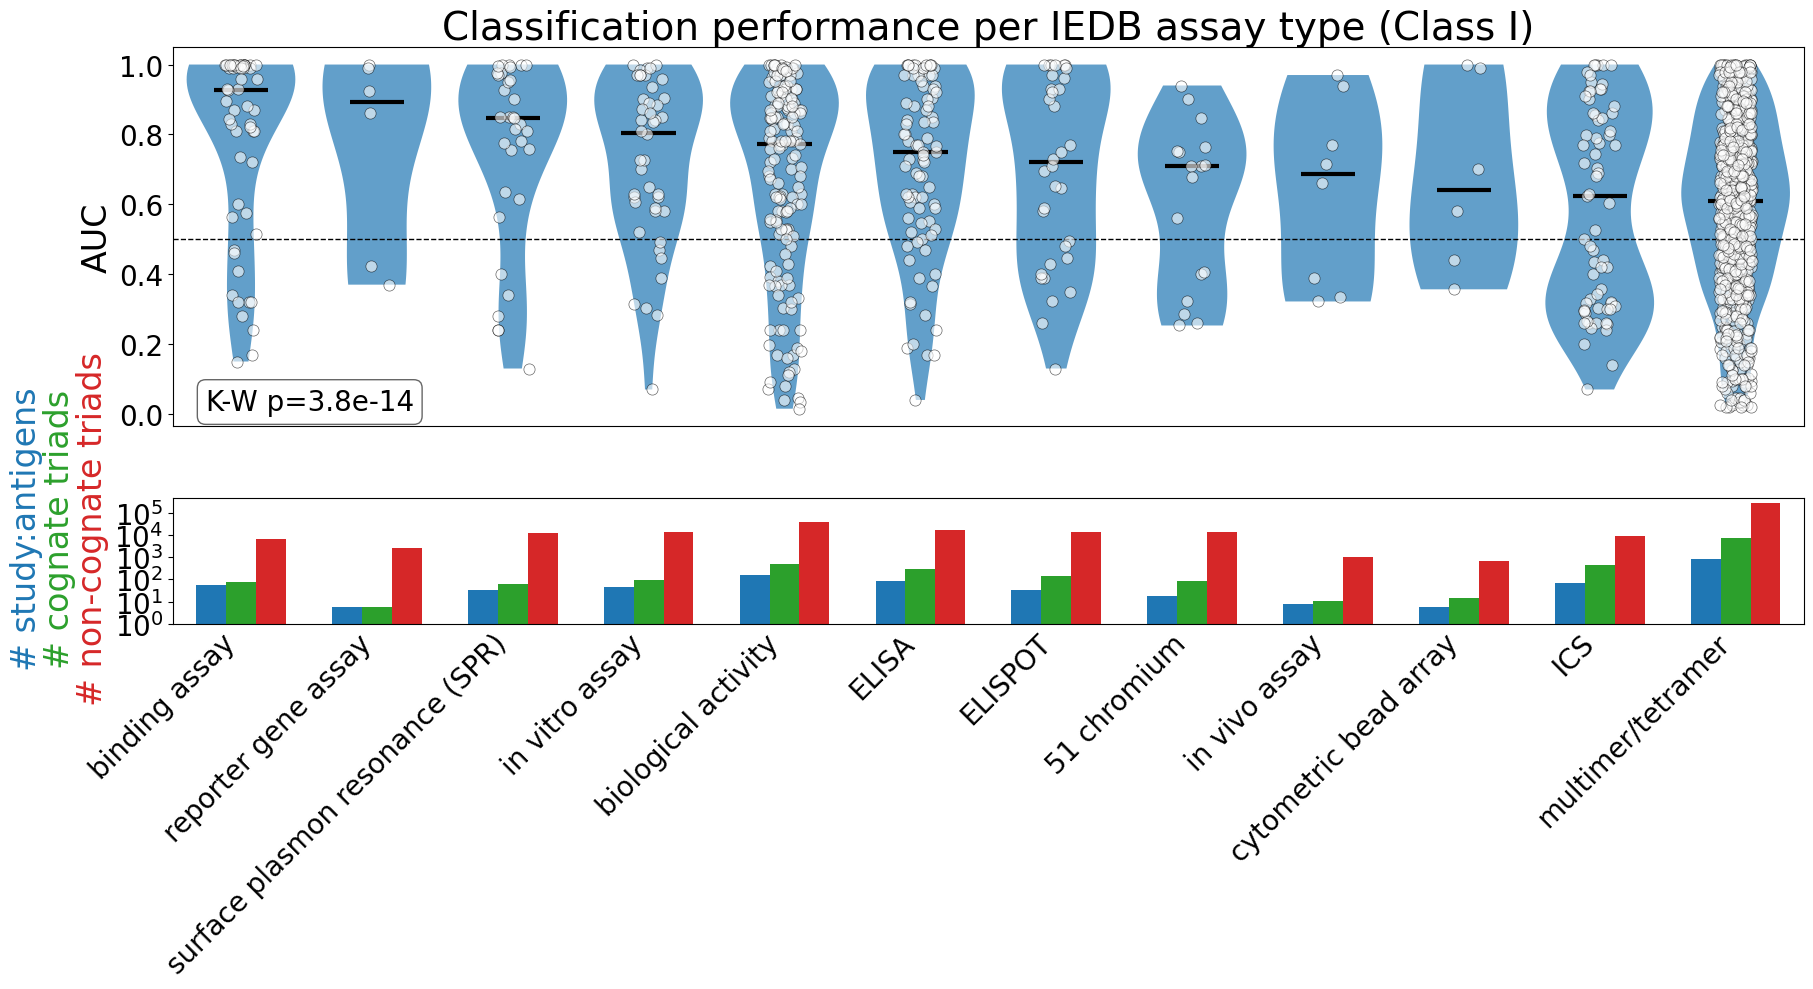

In [9]:
featname = "mean_p_tcr_interface_pae"


auc_partition_I_antigen = (
    (
        auc_at_I.filter(pl.col("featname") == featname)
        .group_by(pl.col("assay_type"))
        .agg(
            pl.col("auc"),
            pl.col("pos_triad"),
            pl.len().alias("n_as"),
            pl.col("neg_triad"),
            pl.col("auc").median().alias("med_auc"),
        )
    )
    .filter(pl.col("n_as") >= 4)
    .sort(by="med_auc", descending=True)
)


plot_violins_scatter(
    auc_partition_I_antigen.select("assay_type").to_series().to_list(),
    auc_partition_I_antigen.select("auc").to_series().to_list(),
    auc_partition_I_antigen.select("pos_triad").to_series().to_list(),
    auc_partition_I_antigen.select("neg_triad").to_series().to_list(),
    title="Classification performance per IEDB assay type (Class I)",
    loc=(0.02, 0.10),
    point_size=65,
)

(<Figure size 850x500 with 1 Axes>,
 <Axes: title={'center': 'AUC vs. Num Positive Triads by Assay Type by Antigen-study (II)'}, xlabel='Number of positive triads', ylabel='AUC'>)

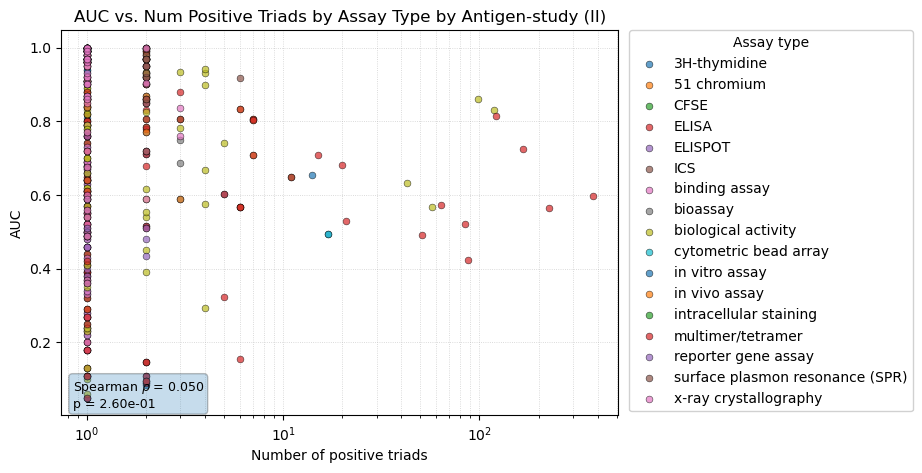

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def plot_auc_vs_pos_triads(
    df: pl.DataFrame, jitter: float = 0.0, s: float = 24, alpha: float = 0.7, title=""
):
    # Categories
    cats = df.get_column("assay_type").unique(maintain_order=True).to_list()

    # Colors
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    cmap = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}

    # Global offset if zeros/nonpositives exist (log-scale safe)
    x_all = df.get_column("pos_triad").to_numpy()
    y_all = df.get_column("auc").to_numpy()
    offset = 1.0 if np.any(x_all <= 0) else 0.0

    fig, ax = plt.subplots(figsize=(8.5, 5))  # a bit wider to make room for legend
    rng = np.random.default_rng()

    for cat in cats:
        sub = df.filter(pl.col("assay_type") == cat)
        x = sub.get_column("pos_triad").to_numpy() + offset
        y = sub.get_column("auc").to_numpy()

        if jitter and jitter > 0:
            x = x + rng.uniform(-jitter, jitter, size=x.size)

        ax.scatter(
            x,
            y,
            s=s,
            alpha=alpha,
            edgecolors="black",
            linewidths=0.4,
            c=cmap[cat],
            label=str(cat),
            zorder=2,
        )

    rho, pval = spearmanr(x_all, y_all)

    ax.set_xscale("log")
    ax.set_xlabel(
        "Number of positive triads" + (" (+1 for zeros)" if offset > 0 else "")
    )
    ax.set_ylabel("AUC")
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.6)

    # Put legend to the right, outside the axes
    leg = ax.legend(
        title="Assay type",
        framealpha=0.9,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )
    plt.subplots_adjust(right=0.78)  # reserve space so legend isn't clipped

    ax.text(
        0.02,
        0.02,
        f"Spearman $\\rho$ = {rho:.3f}\np = {pval:.2e}",
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.25),
    )

    return fig, ax


plot_auc_vs_pos_triads(
    auc_partition_II_antigen.explode(["pos_triad", "auc"]).sort(
        by="assay_type", descending=False
    ),
    title="AUC vs. Num Positive Triads by Assay Type by Antigen-study (II)",
)

(<Figure size 850x500 with 1 Axes>,
 <Axes: title={'center': 'AUC vs. Num Positive Triads by Assay Type by Antigen-study (I)'}, xlabel='Number of positive triads', ylabel='AUC'>)

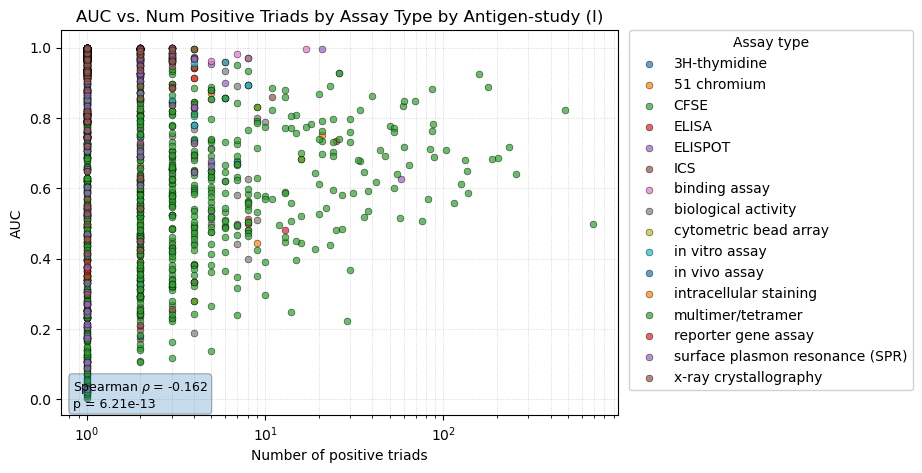

In [ ]:
plot_auc_vs_pos_triads(
    auc_partition_I_antigen.explode(["pos_triad", "auc"]).sort(
        by="assay_type", descending=False
    ),
    title="AUC vs. Num Positive Triads by Assay Type by Antigen-study (I)",
)

## XRAY overlap


In [ ]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
import polars as pl

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")
receptor_reference = pl.read_parquet("../../data/iedb_meta/receptor_reference.parquet")


iedb_II_annot = pl.read_parquet(
    "../../data/iedb_II_full/triad/iedb_II_triad.annotated.parquet"
)

iedb_II_pdb_pmhc = (
    iedb_II_annot.filter(pl.col("pmhc_in_pdb")).select(FORMAT_ANTIGEN_COLS).unique()
)

iedb_II_pdb_triad = (
    iedb_II_annot.explode("receptor_id")
    .explode("references")
    .join(
        receptor_reference,
        left_on=["references", "receptor_id"],
        right_on=["reference_id", "receptor_id"],
    )
)

iedb_II = pl.read_parquet(
    "../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet"
).join(
    iedb_II_pdb_triad.select("job_name", "assay_type", "triad_in_pdb"), on="job_name"
)

iedb_I_annot = pl.read_parquet(
    "../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet"
)

iedb_I_pdb_pmhc = (
    iedb_I_annot.filter(pl.col("pmhc_in_pdb")).select(FORMAT_ANTIGEN_COLS).unique()
)

iedb_I_pdb_triad = (
    iedb_I_annot.explode("receptor_id")
    .explode("references")
    .join(
        receptor_reference,
        left_on=["references", "receptor_id"],
        right_on=["reference_id", "receptor_id"],
    )
)

iedb_I = pl.read_parquet("../../data/iedb_I/triad/iedb_I_triad.conf_af3.parquet").join(
    iedb_I_pdb_triad.select("job_name", "assay_type", "triad_in_pdb"), on="job_name"
)

FileNotFoundError: No such file or directory (os error 2): ../../data/iedb_I_full/triad/iedb_I_triad.annotated.parquet

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'


In [ ]:
excl_af3_II_xray = (
    iedb_II.filter(pl.col("assay_type") == "x-ray crystallography")
    .filter(~pl.col("triad_in_pdb"))
    .select(pl.exclude("triad_in_pdb", "assay_type"))
)

excl_af3_II_xray = pl.concat(
    [
        excl_af3_II_xray,
        iedb_II_conf.filter(~pl.col("cognate")).join(
            excl_af3_II_xray.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ),
    ]
).with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))

incl_af3_II_xray = (
    iedb_II.filter(pl.col("assay_type") == "x-ray crystallography")
    .filter(pl.col("triad_in_pdb"))
    .select(pl.exclude("triad_in_pdb", "assay_type"))
)

incl_af3_II_xray = pl.concat(
    [
        incl_af3_II_xray,
        iedb_II_conf.filter(~pl.col("cognate")).join(
            incl_af3_II_xray.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ),
    ]
).with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))

excl_af3_I_xray = (
    iedb_I.filter(pl.col("assay_type") == "x-ray crystallography")
    .filter(~pl.col("triad_in_pdb"))
    .select(pl.exclude("triad_in_pdb", "assay_type"))
)

excl_af3_I_xray = pl.concat(
    [
        excl_af3_I_xray,
        iedb_I_conf.filter(~pl.col("cognate")).join(
            excl_af3_I_xray.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ),
    ]
).with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))

incl_af3_I_xray = (
    iedb_I.filter(pl.col("assay_type") == "x-ray crystallography")
    .filter(pl.col("triad_in_pdb"))
    .select(pl.exclude("triad_in_pdb", "assay_type"))
)


incl_af3_I_xray = pl.concat(
    [
        incl_af3_I_xray,
        iedb_I_conf.filter(~pl.col("cognate")).join(
            incl_af3_I_xray.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ),
    ]
).with_columns((31 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae"))

ColumnNotFoundError: unable to find column "assay_type"; valid columns: ["job_name", "cognate", "peptide", "mhc_class", "mhc_1_chain", "mhc_1_species", "mhc_1_name", "mhc_1_seq", "mhc_2_chain", "mhc_2_species", "mhc_2_name", "mhc_2_seq", "tcr_1_chain", "tcr_1_species", "tcr_1_seq", "tcr_2_chain", "tcr_2_species", "tcr_2_seq", "tcr_1_cdr_1", "tcr_1_cdr_2", "tcr_1_cdr_2_5", "tcr_1_cdr_3", "tcr_2_cdr_1", "tcr_2_cdr_2", "tcr_2_cdr_2_5", "tcr_2_cdr_3", "receptor_id", "references", "pmhc_in_validation", "chain_iptm", "chain_pair_iptm", "chain_pair_pae_min", "chain_ptm", "fraction_disordered", "has_clash", "iptm", "ptm", "ranking_score", "mean_p_tcr_interface_pae", "mean_tcr_p_interface_pae", "mean_tcr_pmhc_interface_pae", "mean_pmhc_tcr_interface_pae", "mean_p_tcr_interface_contact_prob", "mean_tcr_p_interface_contact_prob", "mean_tcr_pmhc_interface_contact_prob", "mean_pmhc_tcr_interface_contact_prob", "mean_p_tcr_pae", "mean_tcr_p_pae", "mean_mhc_tcr_pae", "mean_tcr_mhc_pae", "mean_p_tcr_c

In [86]:
def antigen_auc_summary_and_plot(
    triad_dataset: pl.DataFrame,
    featname: str,
    grouping_cols,
    mhc_class: str = "I",
    ax: plt.Axes | None = None,
    title: str | None = None,
    jitter: float = 0.01,  # line jitter so curves don't perfectly overlap
    jitter_seed: int | None = 0,
):
    """
    Computes per-antigen ROC (AUC, AUC@0.1, FPR, TPR) + an 'All antigen' summary,
    and plots ROC curves with small jitter. Legend still shows overall AUC only.
    """
    antigens = triad_dataset.select(grouping_cols).unique()
    rows = []

    for row in antigens.iter_rows(named=True):
        antigen_df = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal = triad_dataset.join(antigen_df, on=grouping_cols, nulls_equal=True)

        dat = focal.select(featname, "cognate").to_numpy()
        y_score = dat[:, 0]
        y_true = dat[:, 1]

        fpr, tpr, _ = metrics.roc_curve(y_true, y_score)
        auc = metrics.auc(fpr, tpr)
        auc_01 = metrics.roc_auc_score(y_true, y_score, max_fpr=0.1)

        name = (
            f"{row['mhc_1_name']}::{row['peptide']}"
            if mhc_class == "I"
            else f"{row['mhc_2_name']}::{row['peptide']}"
        )
        rows.append(
            {
                "name": name,
                "roc_auc": float(auc),
                "roc_auc_0_1": float(auc_01),  # standardized pAUC@0.1
                "fpr": fpr.tolist(),
                "tpr": tpr.tolist(),
            }
        )

    # Add overall 'All antigen'
    dat_all = triad_dataset.select(featname, "cognate").to_numpy()
    y_score_all = dat_all[:, 0]
    y_true_all = dat_all[:, 1]
    fpr_all, tpr_all, _ = metrics.roc_curve(y_true_all, y_score_all)
    auc_all = metrics.auc(fpr_all, tpr_all)
    auc_01_all = metrics.roc_auc_score(y_true_all, y_score_all, max_fpr=0.1)

    rows.append(
        {
            "name": "All antigen",
            "roc_auc": float(auc_all),
            "roc_auc_0_1": float(auc_01_all),
            "fpr": fpr_all.tolist(),
            "tpr": tpr_all.tolist(),
        }
    )

    summary_df = pl.DataFrame(rows)

    # ---------- plotting ----------
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    rng = np.random.default_rng(jitter_seed)

    def _jitter_curve(fpr, tpr):
        dx = rng.uniform(-jitter, jitter)
        dy = rng.uniform(-jitter, jitter)
        fpr_j = np.clip(np.asarray(fpr, float) + dx, 0.0, 1.0)
        tpr_j = np.clip(np.asarray(tpr, float) + dy, 0.0, 1.0)
        return fpr_j, tpr_j

    # Plot All antigen first (so it appears first in legend)
    all_row = summary_df.filter(pl.col("name") == "All antigen").row(0, named=True)
    fpr_j, tpr_j = _jitter_curve(all_row["fpr"], all_row["tpr"])
    ax.plot(
        fpr_j,
        tpr_j,
        lw=2.5,
        color="black",
        label=f"{all_row['name']} (AUC {all_row['roc_auc']:.2f}) (AUC@0.1 {all_row['roc_auc_0_1']:.2f})",
        zorder=3,
    )

    # Plot other antigens
    for row in summary_df.filter(pl.col("name") != "All antigen").iter_rows(named=True):
        fpr_j, tpr_j = _jitter_curve(row["fpr"], row["tpr"])
        ax.plot(
            fpr_j,
            tpr_j,
            lw=1.2,
            label=f"{row['name']} (AUC {row['roc_auc']:.2f}) (AUC@0.1 {row['roc_auc_0_1']:.2f})",
            # If you want to also show AUC@0.1, add:
            # f" (AUC@0.1 {row['roc_auc_0_1']:.2f})"
        )

    ax.plot([0, 1], [0, 1], "--", lw=1, color="grey")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    if title:
        ax.set_title(title)
    ax.legend(loc="lower right", fontsize=6)
    ax.grid(True)

    return summary_df, ax

MannwhitneyuResult(statistic=np.float64(204.5), pvalue=np.float64(0.6724707141129821))

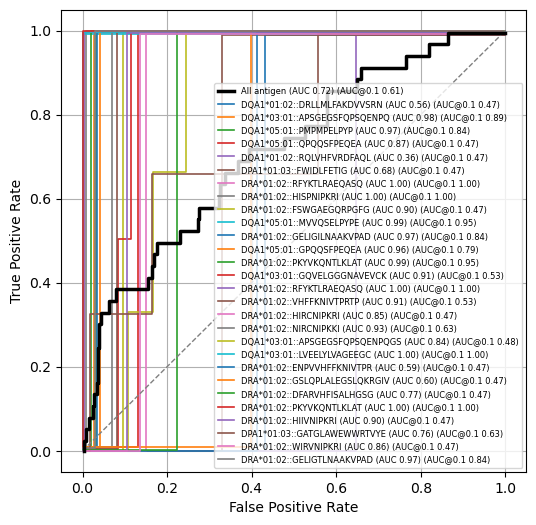

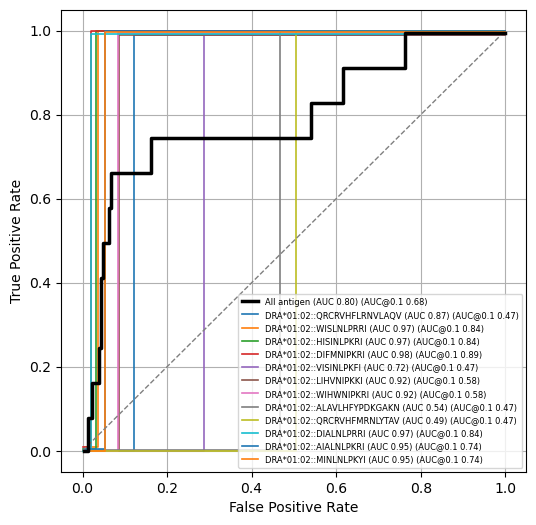

In [102]:
incl_II_df = antigen_auc_summary_and_plot(
    incl_af3_II_xray, "mean_p_tcr_pae", FORMAT_ANTIGEN_COLS
)[0]

excl_II_df = antigen_auc_summary_and_plot(
    excl_af3_II_xray, "mean_p_tcr_pae", FORMAT_ANTIGEN_COLS
)[0]

from scipy.stats import mannwhitneyu

mannwhitneyu(
    incl_II_df.select("roc_auc").to_series().to_numpy(),
    excl_II_df.select("roc_auc").to_series().to_numpy(),
)

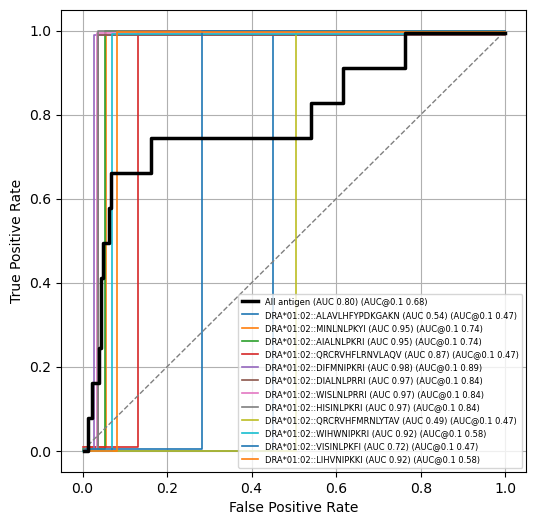